In [ ]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
import src
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import matplotlib.pyplot as plt
import numpy as np 
set_seed(0) 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint
checkpoint_dir = Path("../checkpoints/clf_mixer_attnpl_t_20250905-184209") 
checkpoint_path = checkpoint_dir / "best_model_1.pth"
check_point = torch.load(checkpoint_path,weights_only=False)
args = load_args_from_checkpoint(None, check_point)
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
model = torch.compile(model)
model.eval() 

using time scale base 0.08273330816214566 (key: tau_mean)
tau mean: 0.08273331075906754
using extractor: attn_time_biased_mh time_bias_type: linear extractor_config: {'fuse_mode': 'gate', 'use_ln': True}
load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'resume_path': './checkpoints/mixer_tpp_20250821-223034/best_model_1.pth', 'load_specific_parts': ['encoder'], 'model': 'clf_mixer_attnpl_t', 'use_ema': False, 'batch_size': 64, 'accumulation_steps': 2, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'step_warmup', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.5, 'd_model': 64, 'mixer_model_config': {'input_dim': 1, 'dropout_prob': 0.1, 'd_model': 64, 'n_layer': 1, 'd_intermediate': 128, 'attn_layer_idx': [], 'ssm_cfg': {'layer': 'Mamba2Rotary', 'use_conv': False, 'rotary_emb_scale_base': 102

OptimizedModule(
  (_orig_mod): TaskModel(
    (base_model): MixerModelWrapper(
      (encoder): MixerModel(
        (input_linear): Linear(in_features=1, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (layers): ModuleList(
          (0): Block(
            (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mixer): Mamba2Rotary(
              (in_proj): Linear(in_features=64, out_features=514, bias=False)
              (act): SiLU()
              (norm): RMSNorm()
              (out_proj): Linear(in_features=128, out_features=64, bias=False)
              (rotary_emb): RotaryEmbeddingTime()
            )
            (dropout): Dropout(p=0.1, inplace=False)
            (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mlp): GatedMLP(
              (fc1): Linear(in_features=64, out_features=256, bias=False)
              (fc2): Linear(in_features=128, out_features=64, bias=False)
            )
         

In [6]:
model.eval()
model.extractor.g

Parameter containing:
tensor([0.0251, 0.0148, 0.0381, 0.0291], device='cuda:0', requires_grad=True)

In [5]:
from src.data.preparation import prepare_data
base_dir = f"../data/{args.dataset}"
df, train_loader, val_loader, test_loader, catalog_ds = prepare_data(base_dir=base_dir, args=args,)

CSV files found: ['Chuandian2021.csv']
[✔] Loading cached data from: ../data/ChuanDian/processed/classifier/classifier_Mc_3_Mf_5_Tfore_60_Twindow_180_context_len_1_dt_10.pkl
lengths of samples: min=32, max=981, avg=129.55
Number of positive samples: 808
Number of negative samples: 651
Positive samples: 673, Negative samples: 494
Total samples: 1167, Positive ratio: 0.58, Negative ratio: 0.42
Positive samples: 87, Negative samples: 58
Total samples: 145, Positive ratio: 0.60, Negative ratio: 0.40
Positive samples: 48, Negative samples: 99
Total samples: 147, Positive ratio: 0.33, Negative ratio: 0.67


In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") 

In [6]:
import src.data.event_loader as loader
args.batch_size =32
data_loader = loader.get_dataloader(catalog_ds, batch_size=args.batch_size, shuffle=False, task_type=args.task_type)

Positive samples: 808, Negative samples: 651
Total samples: 1459, Positive ratio: 0.55, Negative ratio: 0.45


In [7]:
for x, y in val_loader:
    x, y = x.to(device), y.to(device)
    break

In [15]:
model.eval()
model.extractor.t_mlp.to(device)
x = torch.linspace(0, 1, 100).unsqueeze(1)  
x = x.to(device)  
gamma, beta = model.extractor.t_mlp(x).chunk(2, dim=-1)  

In [18]:
def predict_all(model, data_loader, device):
    y_pred_list = []
    y_list = []
    model.eval()  # Ensure the model is in evaluation mode
    with torch.no_grad():  # Disable gradient computation for inference
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            y_pred = model(x)
            y_pred_list.append(y_pred.detach().cpu())
            y_list.append(y.detach().cpu())

    y_pred_all = torch.cat(y_pred_list, dim=0).numpy()
    y_all = torch.cat(y_list, dim=0).numpy()
    return y_pred_all, y_all


In [19]:
from src.utils.metrics import classification_metrics, log_metrics, plot_and_save_roc_curve, plot_classification_distribution
y_pred_all, y_all = predict_all(model,val_loader, device)
start=0
end =400
classification_metrics(y_all[start:end], y_pred_all[start:end])  

/root/miniconda3/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:167: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


{'precision': 0.5972222222222222,
 'recall': 0.9885057471264368,
 'f1': 0.7445887445887446,
 'auc': 0.7043202536662703,
 'fpr': 1.0,
 'tpr': 0.9885057471264368,
 'R': -0.011494252873563204,
 'conf': 0.0,
 'threshold': 0.29452523589134216}

In [20]:
# plt.plot(y_pred_all)
y_pred_all_nl = (y_pred_all - y_pred_all.min()) / (y_pred_all.max() - y_pred_all.min())

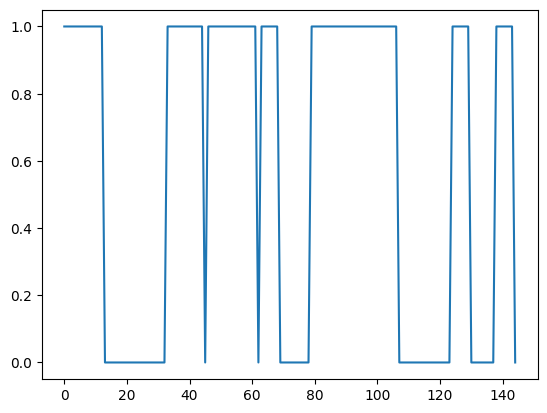

In [21]:
plt.plot(y_all,)
# plt.plot(y_pred_all_nl>0.5)
# plt.plot(y_pred_all_nl)

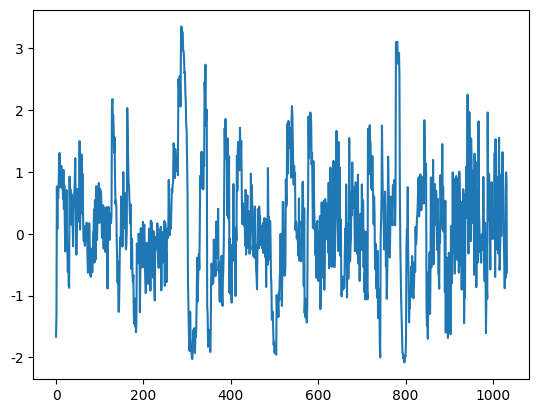

In [ ]:
plt.plot(y_pred_all)